## 0. Persiapan

Bagian ini berisi library dan beberapa pengaturan yang dipakai selama analisis.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

# Pengaturan yang dipakai di notebook
CSV_PATH = "maritime_border_data.csv"
TARGET = "Status_Radar"
CLASSES = ["Aktif", "Terganggu", "Mati"]
CLASS_KRITIS = "Mati"  # kondisi radar paling buruk
DROP_COLS = ["No", "Kode_Sektor", "Laporan_Intelijen_Singkat"]
# Eskalasi dipakai sebagai fitur, diubah menjadi angka (makin besar = makin berbahaya)
ESKALASI_MAP = {"Normal": 0, "Siaga Maritim": 1, "Intervensi Militer": 2}
NORM_COLS = "all"
TEST_SIZE = 0.20
RANDOM_STATE = 42
PREPROCESSED_CSV_PATH = "preprocessed_radar_data.csv"

MODEL_COLORS = {"SVM": "#2a78d6", "Random Forest": "#eb6834"}
sns.set_theme(style="whitegrid", context="notebook")


# Bagian 1 — Preprocessing dan Analisis

## 1.1 Membaca data

In [2]:
df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")  # utf-8-sig strips a BOM if present
# Hapus simbol "●" pada Status_Radar, mis. "● Aktif" -> "Aktif"
df["Status_Radar"] = df["Status_Radar"].str.replace("●", "", regex=False).str.strip()
print("Shape:", df.shape)
df.head()

Shape: (350, 9)


,No,Kode_Sektor,Sinyal_AIS_Mencurigakan,Frekuensi_Transmisi_Ilegal,Indeks_Pelanggaran_Perbatasan,Kecepatan_Angin_Knot,Status_Radar,Laporan_Intelijen_Singkat,Eskalasi
0,1,SEK-NATUNA-01,45,393.8,8.3,57,Mati,Penerobosan terkoordinasi armada tak berbender...,Intervensi Militer
1,2,SEK-AMBALAT-01,15,455.0,5.7,41,Aktif,Anomali akustik bawah air terdeteksi hidrofon ...,Siaga Maritim
2,3,SEK-ARAFURA-01,9,683.2,1.2,9,Terganggu,Pengecekan sinyal AIS menunjukkan verifikasi M...,Normal
3,4,SEK-MALAKA-01,41,770.0,8.6,27,Aktif,Deteksi transmisi radio militer terenkripsi fr...,Intervensi Militer
4,5,SEK-SABANG-01,22,527.5,6.1,29,Terganggu,Kapal kargo mematikan transponder AIS selama 4...,Siaga Maritim


In [3]:
print("Class distribution:")
print(df[TARGET].value_counts())

Class distribution:
Status_Radar
Aktif        212
Terganggu     83
Mati          55
Name: count, dtype: int64


## 1.2 Mengecek dan menangani missing value

Pertama saya cek dulu jumlah data kosong di setiap kolom.

Untuk percobaan ini, baris yang masih memiliki nilai kosong pada kolom yang digunakan untuk analisis akan dihapus menggunakan `dropna()`.

In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None")

# Hapus baris yang masih punya nilai kosong pada kolom yang digunakan.
rows_before = len(df)
df_clean = df.dropna(subset=[c for c in df.columns if c not in DROP_COLS]).reset_index(drop=True)
print(f"\nRows before: {rows_before} | after: {len(df_clean)} | dropped: {rows_before - len(df_clean)}")

# Ubah Eskalasi (teks) menjadi angka supaya bisa dipakai sebagai fitur.
df_clean["Eskalasi"] = df_clean["Eskalasi"].map(ESKALASI_MAP)
print("\nEskalasi setelah encoding:")
print(df_clean["Eskalasi"].value_counts().sort_index())


Missing values per column:
None

Rows before: 350 | after: 350 | dropped: 0

Eskalasi setelah encoding:
Eskalasi
0    121
1    159
2     70
Name: count, dtype: int64


## 1.3 Normalisasi fitur

Fitur numerik memiliki skala yang berbeda-beda. Karena itu saya menggunakan **Min-Max Scaling** supaya nilainya berada pada rentang 0 sampai 1.

Normalisasi dilakukan setelah data dibagi menjadi train dan test. Dengan cara ini, scaler hanya belajar dari data training sehingga data test tidak ikut memengaruhi proses preprocessing.

Untuk model, proses yang sama kemudian digunakan pada data training dan data testing.

In [5]:
X = df_clean.drop(columns=DROP_COLS + [TARGET])
y = df_clean[TARGET]

# Ambil fitur numerik saja untuk model.
FEATURES = X.select_dtypes(include="number").columns.tolist()
X = X[FEATURES]

if NORM_COLS == "all":
    NORM_COLS = FEATURES

print("Features:", FEATURES)
print("Normalized:", NORM_COLS)

# Bagi data dulu, baru fit scaler dari data training.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

scaler = MinMaxScaler()
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

X_train_norm[NORM_COLS] = scaler.fit_transform(X_train[NORM_COLS])
X_test_norm[NORM_COLS] = scaler.transform(X_test[NORM_COLS])

# Simpan versi data yang sudah dinormalisasi.
X_all_norm = X.copy()
X_all_norm[NORM_COLS] = scaler.transform(X[NORM_COLS])

preprocessed_df = X_all_norm.copy()
preprocessed_df[TARGET] = y.values
preprocessed_df.to_csv(PREPROCESSED_CSV_PATH, index=False, encoding="utf-8-sig")

print(f"\nPreprocessed CSV saved to: {PREPROCESSED_CSV_PATH}")
print("Saved shape:", preprocessed_df.shape)
display(preprocessed_df.head())

print("\nBefore normalization:")
display(X.describe().loc[["min", "max"]].round(3))

print("After normalization:")
display(X_all_norm.describe().loc[["min", "max"]].round(3))


Features: ['Sinyal_AIS_Mencurigakan', 'Frekuensi_Transmisi_Ilegal', 'Indeks_Pelanggaran_Perbatasan', 'Kecepatan_Angin_Knot', 'Eskalasi']
Normalized: ['Sinyal_AIS_Mencurigakan', 'Frekuensi_Transmisi_Ilegal', 'Indeks_Pelanggaran_Perbatasan', 'Kecepatan_Angin_Knot', 'Eskalasi']
Train: 280 rows | Test: 70 rows

Preprocessed CSV saved to: preprocessed_radar_data.csv
Saved shape: (350, 6)


,Sinyal_AIS_Mencurigakan,Frekuensi_Transmisi_Ilegal,Indeks_Pelanggaran_Perbatasan,Kecepatan_Angin_Knot,Eskalasi,Status_Radar
0,0.918367,0.325831,0.820225,1.000000,1.0,Mati
1,0.306122,0.394357,0.528090,0.692308,0.5,Aktif
2,0.183673,0.649871,0.022472,0.076923,0.0,Terganggu
3,0.836735,0.747061,0.853933,0.423077,1.0,Aktif
4,0.448980,0.475535,0.573034,0.461538,0.5,Terganggu



Before normalization:


,Sinyal_AIS_Mencurigakan,Frekuensi_Transmisi_Ilegal,Indeks_Pelanggaran_Perbatasan,Kecepatan_Angin_Knot,Eskalasi
min,0.0,102.8,1.0,5.0,0.0
max,49.0,995.9,9.9,57.0,2.0


After normalization:


,Sinyal_AIS_Mencurigakan,Frekuensi_Transmisi_Ilegal,Indeks_Pelanggaran_Perbatasan,Kecepatan_Angin_Knot,Eskalasi
min,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0


## 1.4 Melihat korelasi antar fitur

Di bagian ini saya melihat hubungan antar fitur numerik menggunakan correlation heatmap.

Nilai korelasi mendekati 1 atau -1 menunjukkan hubungan yang lebih kuat, sedangkan nilai yang mendekati 0 menunjukkan hubungan yang lebih lemah.

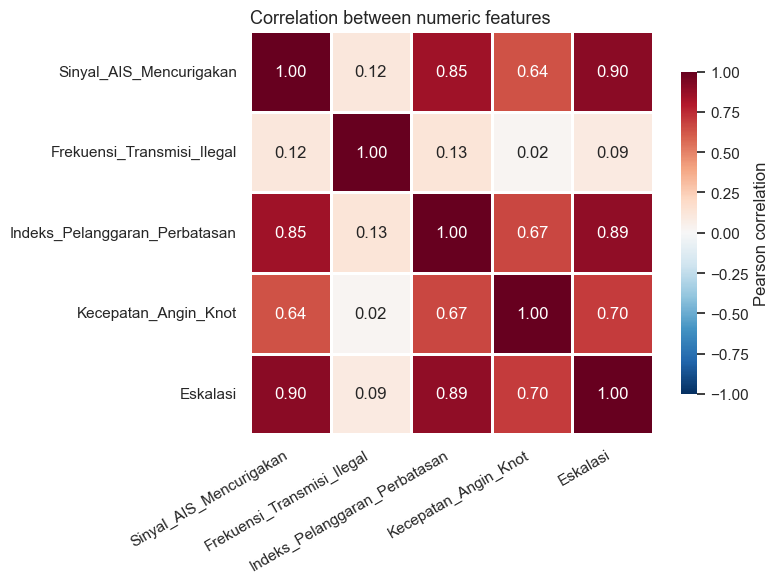

In [6]:
# Correlation is calculated on the numeric features.
# Min-Max scaling does not change Pearson correlation for these features.
corr = X.corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=2,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation", "shrink": 0.8},
    ax=ax
)

ax.set_title("Correlation between numeric features", loc="left", fontsize=13)
ax.grid(False)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Bagian 2 — Pembuatan dan Pengujian Model

## 2.1 Data training dan testing

Data sudah dibagi menjadi **80% training dan 20% testing** pada bagian sebelumnya.

Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk melihat bagaimana model bekerja pada data yang belum digunakan saat training.

Hasil data yang sudah dinormalisasi juga disimpan ke file CSV agar bisa dipakai kembali jika diperlukan.

In [7]:
# The train/test split was already performed before normalization.
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")
pd.DataFrame({"train": y_train.value_counts(), "test": y_test.value_counts()}).loc[CLASSES]


Train: 280 rows | Test: 70 rows


,train,test
Status_Radar,,
Aktif,170,42
Terganggu,66,17
Mati,44,11


## 2.2 Membuat model

Saya mencoba dua model:
- **SVM**
- **Random Forest**

`class_weight="balanced"` digunakan karena jumlah data antar kelas tidak sepenuhnya seimbang.

In [8]:
# Data sudah dinormalisasi sebelum masuk ke model.
models = {
    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}


## 2.3 Training dan prediksi

Kedua model dilatih menggunakan data training. Setelah itu model digunakan untuk memprediksi data testing.

Selain hasil prediksi, waktu training dan waktu prediksi juga dicatat supaya keduanya bisa dibandingkan.

In [9]:
results = {}

for name, model in models.items():
    # Catat waktu training.
    t0 = time.perf_counter()
    model.fit(X_train_norm, y_train)
    train_time = time.perf_counter() - t0

    # Catat waktu prediksi.
    t0 = time.perf_counter()
    y_pred = model.predict(X_test_norm)
    predict_time = time.perf_counter() - t0

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "train_time": train_time,
        "predict_time": predict_time,
    }

    print(f"===== {name} =====")
    print(f"Train time:   {train_time:.6f} s")
    print(f"Predict time: {predict_time:.6f} s")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred, labels=CLASSES, zero_division=0))


===== SVM =====
Train time:   0.007004 s
Predict time: 0.002209 s
Accuracy: 0.6000
              precision    recall  f1-score   support

       Aktif       0.71      0.57      0.63        42
   Terganggu       0.37      0.41      0.39        17
        Mati       0.65      1.00      0.79        11

    accuracy                           0.60        70
   macro avg       0.57      0.66      0.60        70
weighted avg       0.61      0.60      0.60        70

===== Random Forest =====
Train time:   0.291637 s
Predict time: 0.069057 s
Accuracy: 0.5857
              precision    recall  f1-score   support

       Aktif       0.66      0.74      0.70        42
   Terganggu       0.12      0.06      0.08        17
        Mati       0.60      0.82      0.69        11

    accuracy                           0.59        70
   macro avg       0.46      0.54      0.49        70
weighted avg       0.52      0.59      0.55        70



In [10]:
# Cek isi hasil sebelum dibuat tabel ringkasan.
for name, res in results.items():
    print(name, list(res.keys()))


SVM ['model', 'y_pred', 'train_time', 'predict_time']
Random Forest ['model', 'y_pred', 'train_time', 'predict_time']


## 2.4 Confusion matrix

Confusion matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada masing-masing kelas.

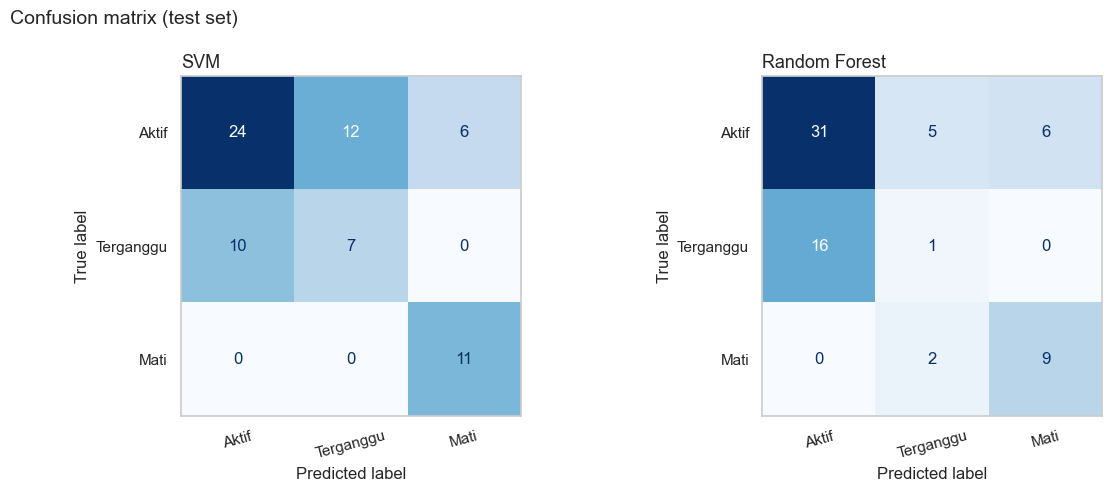

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"], labels=CLASSES)
    ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name, loc="left", fontsize=13)
    ax.grid(False)
    ax.tick_params(axis="x", labelrotation=15)
fig.suptitle("Confusion matrix (test set)", x=0.01, ha="left", fontsize=14)
plt.tight_layout()
plt.show()

## 2.5 F1-score tiap kelas

F1-score membantu melihat performa model pada masing-masing kelas.

Ini cukup penting karena dataset memiliki lebih dari satu kategori status radar dan jumlah data tiap kategori tidak sama.

In [12]:
f1_table = pd.DataFrame(
    {name: f1_score(y_test, res["y_pred"], labels=CLASSES, average=None, zero_division=0)
     for name, res in results.items()},
    index=CLASSES)
f1_table.index.name = "Class"
f1_table.round(3)

,SVM,Random Forest
Class,,
Aktif,0.632,0.697
Terganggu,0.389,0.080
Mati,0.786,0.692


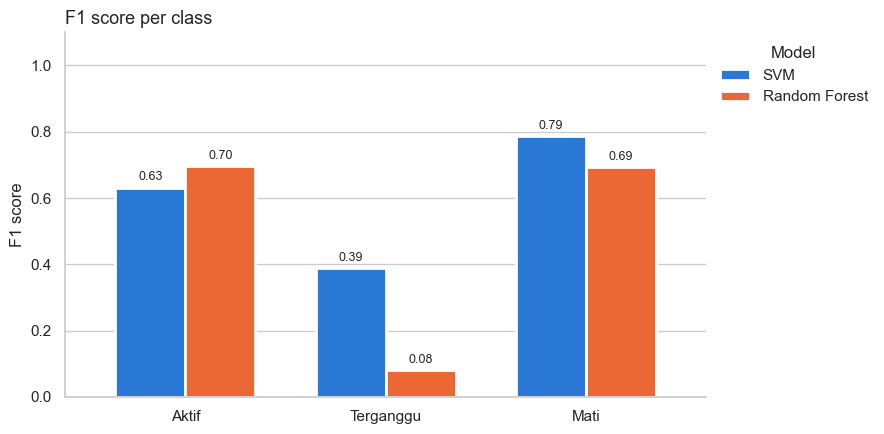

In [13]:
ax = f1_table.plot.bar(figsize=(9, 4.5), width=0.7, rot=0, edgecolor="white", linewidth=2,
                      color=[MODEL_COLORS[m] for m in f1_table.columns])
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)
ax.set_ylim(0, 1.1)
ax.grid(axis="x", visible=False)
ax.set_ylabel("F1 score")
ax.set_xlabel("")
ax.set_title("F1 score per class", loc="left", fontsize=13)
ax.legend(title="Model", frameon=False, loc="upper left", bbox_to_anchor=(1, 1))
sns.despine()
plt.tight_layout()
plt.show()

In [14]:
for name, res in results.items():
    print(f"===== {name} =====")
    print(classification_report(y_test, res["y_pred"], labels=CLASSES, digits=3, zero_division=0))

===== SVM =====
              precision    recall  f1-score   support

       Aktif      0.706     0.571     0.632        42
   Terganggu      0.368     0.412     0.389        17
        Mati      0.647     1.000     0.786        11

    accuracy                          0.600        70
   macro avg      0.574     0.661     0.602        70
weighted avg      0.615     0.600     0.597        70

===== Random Forest =====
              precision    recall  f1-score   support

       Aktif      0.660     0.738     0.697        42
   Terganggu      0.125     0.059     0.080        17
        Mati      0.600     0.818     0.692        11

    accuracy                          0.586        70
   macro avg      0.462     0.538     0.490        70
weighted avg      0.520     0.586     0.546        70



## 2.6 Ringkasan hasil percobaan

Di sini hasil dari kedua model dirangkum supaya lebih mudah dibandingkan.

In [15]:
summary = pd.DataFrame({
    name: {
        "Accuracy": accuracy_score(y_test, res["y_pred"]),
        "F1 (macro)": f1_score(y_test, res["y_pred"], average="macro", zero_division=0),
        "F1 (weighted)": f1_score(y_test, res["y_pred"], average="weighted", zero_division=0),
        **{f"F1 {c}": f1_table.loc[c, name] for c in CLASSES},
        "Train time (ms)": res["train_time"] * 1000,
        "Predict time (ms)": res["predict_time"] * 1000,
    }
    for name, res in results.items()
}).T
summary.round(3)

,Accuracy,F1 (macro),F1 (weighted),F1 Aktif,F1 Terganggu,F1 Mati,Train time (ms),Predict time (ms)
SVM,0.600,0.602,0.597,0.632,0.389,0.786,7.004,2.209
Random Forest,0.586,0.490,0.546,0.697,0.080,0.692,291.637,69.057


## 2.7 Membandingkan hasil model

Perbandingan utama menggunakan **macro F1**, karena nilai ini memberikan bobot yang sama untuk setiap kelas.

Jika perbedaan macro F1 kedua model sangat kecil, waktu eksekusi digunakan sebagai pertimbangan tambahan.

In [16]:
TIE_MARGIN = 0.02

ranked = summary.sort_values("F1 (macro)", ascending=False)
best, other = ranked.index[0], ranked.index[1]
gap = ranked.loc[best, "F1 (macro)"] - ranked.loc[other, "F1 (macro)"]
total_time = summary["Train time (ms)"] + summary["Predict time (ms)"]

if gap < TIE_MARGIN:
    winner = total_time.idxmin()
    reason = (f"selisih macro F1 hanya {gap:.3f}, jadi waktu eksekusi "
              f"menjadi pertimbangan. Total waktu model terpilih "
              f"{total_time[winner]:.1f} ms.")
else:
    winner = best
    reason = (f"macro F1 lebih tinggi sebesar {gap:.3f} "
              f"({ranked.loc[best, 'F1 (macro)']:.3f} dibanding "
              f"{ranked.loc[other, 'F1 (macro)']:.3f}).")

loser = [m for m in summary.index if m != winner][0]

print(f"Model yang dipilih berdasarkan hasil percobaan: {winner}")
print(f"Alasan: {reason}\n")

print("Perbandingan F1-score tiap kelas:")
for c in CLASSES:
    w, l = f1_table.loc[c, winner], f1_table.loc[c, loser]
    if w > l:
        flag = "lebih tinggi"
    elif w == l:
        flag = "sama"
    else:
        flag = "lebih rendah"
    print(f"  {c:<20} {winner}: {w:.3f} | {loser}: {l:.3f} -> {flag}")

print(
    f"\nF1-score kelas {CLASS_KRITIS}: "
    f"{winner} = {f1_table.loc[CLASS_KRITIS, winner]:.3f}"
)


Model yang dipilih berdasarkan hasil percobaan: SVM
Alasan: macro F1 lebih tinggi sebesar 0.112 (0.602 dibanding 0.490).

Perbandingan F1-score tiap kelas:
  Aktif                SVM: 0.632 | Random Forest: 0.697 -> lebih rendah
  Terganggu            SVM: 0.389 | Random Forest: 0.080 -> lebih tinggi
  Mati                 SVM: 0.786 | Random Forest: 0.692 -> lebih tinggi

F1-score kelas Mati: SVM = 0.786


## 2.8 Kesimpulan

Kesimpulan di bawah akan mengikuti hasil yang benar-benar keluar ketika notebook dijalankan.

Secara umum, model tidak hanya dilihat dari accuracy. Saya juga melihat macro F1 dan F1-score setiap kelas, terutama kelas **Mati** (radar mati), serta waktu training dan prediksi.

> Catatan: dataset yang digunakan relatif kecil, sehingga hasil satu kali train-test split masih bisa berubah jika pembagian datanya berubah. Untuk hasil yang lebih kuat, pengujian dapat dilanjutkan dengan cross-validation.

In [17]:
# Kesimpulan singkat berdasarkan hasil yang diperoleh
print("KESIMPULAN")
print("=" * 50)
print(f"Berdasarkan percobaan ini, model yang dipilih adalah {winner}.")
print(f"Macro F1 {winner}: {summary.loc[winner, 'F1 (macro)']:.3f}")
print(f"Accuracy {winner}: {summary.loc[winner, 'Accuracy']:.3f}")
print(f"F1 {CLASS_KRITIS}: {f1_table.loc[CLASS_KRITIS, winner]:.3f}")
print(f"Total waktu training + prediksi: {total_time[winner]:.2f} ms")
print()



KESIMPULAN
Berdasarkan percobaan ini, model yang dipilih adalah SVM.
Macro F1 SVM: 0.602
Accuracy SVM: 0.600
F1 Mati: 0.786
Total waktu training + prediksi: 9.21 ms

